# Aprendizaje anti-Hebbiano
## Dinámica del sistema

$$
\begin{align*}
&\dot{x} = W x &\\

&\dot{W} = \alpha (I - xx^T) &
\end{align*}
$$

## Algoritmo de evolución
He empleado una integración por Euler simple y funciona razonablemente bien para $dt\leq 0.1$
$$
\begin{align*}
x_{n+1, i} = x_{n, i} + W_{ij}x_jdt\\
W_{n+1, ij} = W_{n, ij} + \alpha(\delta_{i, j} - x_ix_j)dt
\end{align*}
$$

El siguiente diagrama de fase muestra como sistema unidimensional alcanza la estabilidad siempre 
independientemente del valor de α (siendo siempre positivo), 
alcanzando una orbita estacionaria en torno a x = ±1 y W = 0 de periodo T = 1/sqrt(2α).


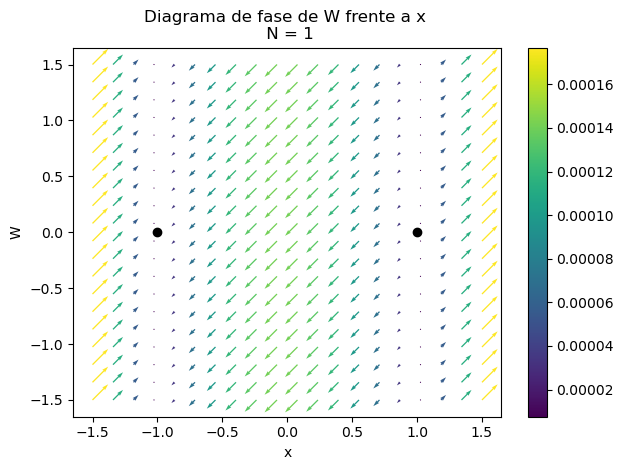

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import scipy.optimize as op


# Sistema de ecuaciones diferenciales 
def equations(vars):
   # Parámetros del sistema
   alpha = 0.0001
   beta = 1
   gamma = 1
   delta = 1
   x, y = vars

   fx = y * x
   fy = -alpha * (1 - x ** 2)

   return fx, fy

# Buscamos los estados estacionarios
x_i = np.linspace(-10, 10, 100)
y_i = np.linspace(-10, 10, 100)
initial_guesses = np.stack((x_i, y_i), axis=1)

stat = [[], []]

for guess in initial_guesses:
   result = op.root(fun=equations, x0=guess)
   if result.success:
      roots = np.round(result.x, 2)
      stat = np.column_stack((stat, roots))

x_0, y_0 = np.unique(np.round(stat), axis=1)



plt.scatter(x_0, y_0, marker='o', c='k' )

x_max = x_0.max()
y_max = y_0.max()

x_min = np.abs(x_0.min())
y_min = np.abs(y_0.min())

# Rango de las variables
x = np.linspace(-1.5 * x_min, 1.5 * x_max, 20)
y = np.linspace(-1.5 * y_min, 1.5 * y_max, 20)


n_cells = 20

if np.abs(x_max) < 10e-5:
   x = np.linspace(-1.5, 1.5, n_cells)

if np.abs(y_max) < 10e-5:
   y = np.linspace(-1.5, 1.5, n_cells)


# Creamos el grid con las posiciones
x_grid, y_grid = np.meshgrid(x, y)

fx = fy = np.zeros_like(x_grid)

for i in range(n_cells):
   for j in range(n_cells):
      fx[i, j], fy[i, j] = equations([x_grid[i, j], y_grid[i, j]])

magnitude = np.sqrt(fx ** 2 + fy ** 2)

# Graficamos el campo vectorial
plt.quiver(x, y, fx, fy, magnitude , cmap='viridis', norm='linear')
plt.colorbar()
plt.xlabel('x')
plt.ylabel('W')
plt.title("Diagrama de fase de W frente a x \n N = 1")
plt.tight_layout()
print("El siguiente diagrama de fase muestra como sistema unidimensional alcanza la estabilidad siempre \n" \
"independientemente del valor de α (siendo siempre positivo), \n" \
"alcanzando una orbita estacionaria en torno a x = ±1 y W = 0 de periodo T = 1/sqrt(2α).")